In [4]:
# === SETUP DEL ENTORNO ===

# 1. Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
from pandas.api.types import is_numeric_dtype
warnings.filterwarnings('ignore')

print("✅ Todas las librerías importadas correctamente")

# 3. Configurar visualizaciones
plt.style.use('seaborn-v0_8')  # estilo visual (ej: 'seaborn-v0_8', 'default', 'classic')
sns.set_palette("viridis")  # paleta de colores (ej: 'husl', 'Set1', 'viridis')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("🎨 Configuración de visualizaciones lista!")

✅ Todas las librerías importadas correctamente
🎨 Configuración de visualizaciones lista!


In [7]:
# === CARGAR DATASET AMES HOUSING ===

# 1. Cargar dataset base
!curl -L -o ames-housing-dataset.zip https://www.kaggle.com/api/v1/datasets/download/shashanknecrothapa/ames-housing-dataset
!unzip -o ames-housing-dataset.zip
df = pd.read_csv('AmesHousing.csv')


print("🏠 DATASET: Ames Housing")
print(f"   📊 Forma original: {df.shape}")
print(f"   📋 Columnas: {list(df.columns)}")

# 2. Crear missing data sintético para práctica
np.random.seed(42)  # para reproducibilidad

# Simular MCAR en Year Built (8% missing aleatorio)
# "Los valores faltan al azar: que falte un Year Built no depende de la edad ni del propio Year Built"
missing_year = np.random.random(len(df)) < 0.08
df.loc[missing_year, 'Year Built'] = np.nan

# Simular MAR en Garage Area (missing relacionado con Garage Type)
# "Los faltantes de Garage Area se concentran en ciertos tipos de garaje (variable observada)"
df.loc[df['Garage Type'] == 'None', 'Garage Area'] = df.loc[df['Garage Type'] == 'None', 'Garage Area'].sample(frac=0.7, random_state=42)

# Simular MNAR en SalePrice (missing relacionado con precio alto)
# "Los faltantes dependen del propio valor: quienes tienen precios altos no reportan precio"
high_price = df['SalePrice'] > df['SalePrice'].quantile(0.85)
df.loc[high_price, 'SalePrice'] = df.loc[high_price, 'SalePrice'].sample(frac=0.2, random_state=42)

print("\n🔍 Missing data sintético creado:")
print(df.value_counts().sum())  # método para contar valores faltantes por columna

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed
  0      0   0      0   0      0      0      0                              0
100 184.6k 100 184.6k   0      0 109.7k      0   00:01   00:01              0
Archive:  ames-housing-dataset.zip
  inflating: AmesHousing.csv         
🏠 DATASET: Ames Housing
   📊 Forma original: (2930, 82)
   📋 Columnas: ['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 

In [ ]:
# === EXPLORACIÓN BÁSICA ===

# 1. Información general del dataset
print("=== INFORMACIÓN GENERAL ===")
print(df.info())  # método que muestra tipos de datos, memoria y valores no nulos

# 2. Estadísticas descriptivas
print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(df.describe())  # método que calcula estadísticas descriptivas

# 3. Tipos de datos
print("\n=== TIPOS DE DATOS ===")
print(df.dtypes)  # atributo que muestra tipos de datos por columna

# 4. Verificar missing data
print("\n=== MISSING DATA POR COLUMNA ===")
missing_count = df.value_counts().sum()  # contar valores faltantes
missing_pct = (missing_count / len(df)) * 100  # calcular porcentaje

missing_stats = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': missing_count,
    'Missing_Percentage': missing_pct
})
print(missing_stats[missing_stats['Missing_Count'] > 0])

# 5. Análisis de memoria
print("\n=== ANÁLISIS DE MEMORIA ===")
total_bytes = df.memory_usage(deep=True).sum()  # método para memoria en bytes
print(f"Memoria total del DataFrame: {total_bytes / (1024**2):.2f} MB")
print(f"Memoria por columna:")
for col in df.columns:
    memory_usage = df[col].memory_usage()  # método para memoria de una columna
    print(f"  {col}: {memory_usage / 1024:.2f} KB")

# 6. Análisis de duplicados
print("\n=== ANÁLISIS DE DUPLICADOS ===")
duplicates = df.duplicated()  # método para detectar filas duplicadas
print(f"Número de filas duplicadas: {duplicates.sum()}")
if duplicates.sum() > 0:
    print("Primeras 5 filas duplicadas:")
    print(df[df.duplicated()].head())  # método para filtrar duplicados

=== INFORMACIÓN GENERAL ===
<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 1

Columnas con missing data: 29
Columnas: ['Lot Frontage', 'Alley', 'Year Built', 'Mas Vnr Type', 'Mas Vnr Area', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Electrical', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond', 'Pool QC', 'Fence', 'Misc Feature', 'SalePrice']


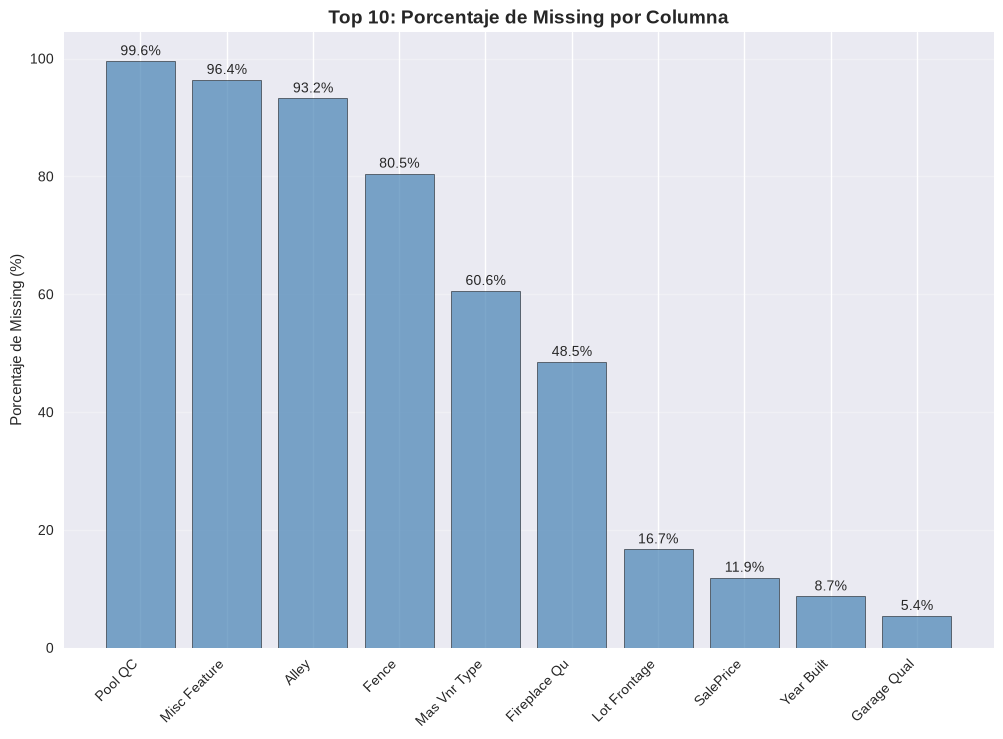

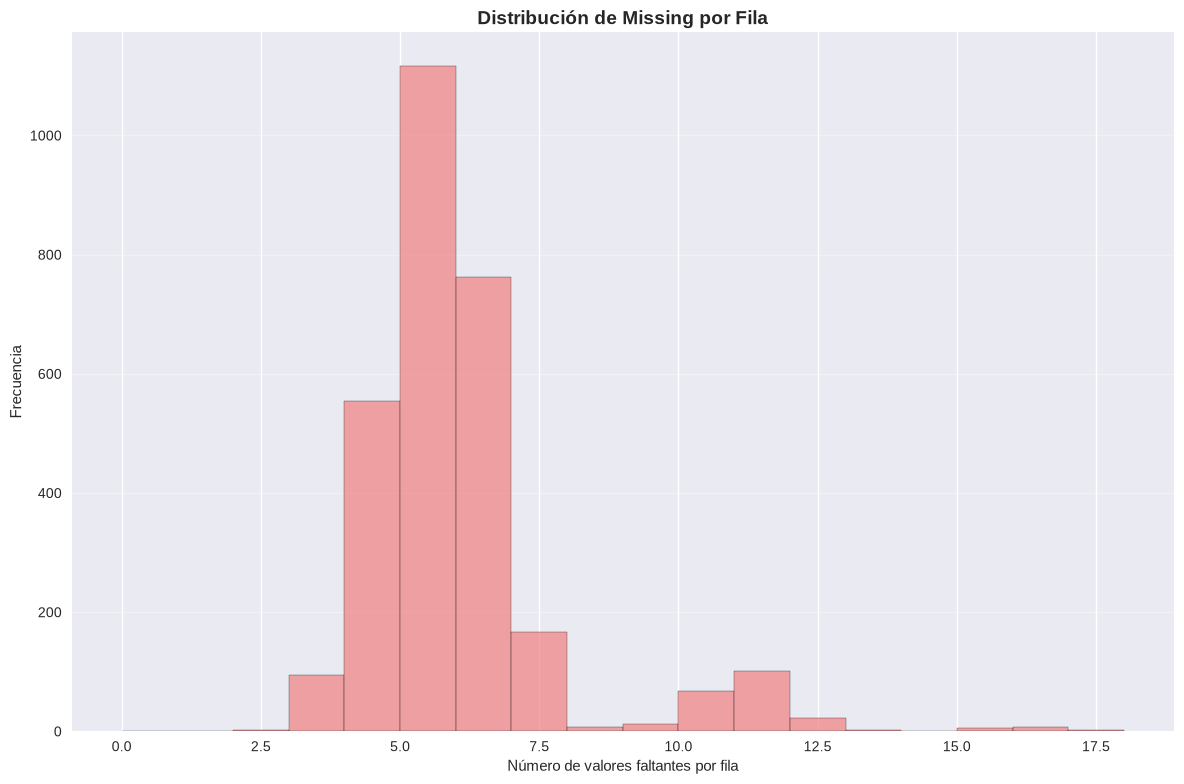

In [12]:
# === ANÁLISIS DE PATRONES DE MISSING DATA ===

# 1. Filtrar solo columnas con missing data para visualización
missing_columns = df.columns[df.isnull().any()].tolist()  # método para detectar missing
print(f"Columnas con missing data: {len(missing_columns)}")
print(f"Columnas: {missing_columns}")

# 2. Visualización mejorada sin missingno
plt.subplot(1, 1, 1)
if len(missing_columns) > 0:
    # Crear estadísticas de missing solo para columnas con missing data
    missing_count = df[missing_columns].isnull().sum()  # método para contar missing
    missing_pct = (missing_count / len(df)) * 100  # calcular porcentaje

    missing_stats_filtered = pd.DataFrame({
        'Column': missing_columns,
        'Missing_Count': missing_count,
        'Missing_Percentage': missing_pct
    }).sort_values('Missing_Percentage', ascending=False).head(10)

    # Crear gráfico de barras más limpio
    bars = plt.bar(range(len(missing_stats_filtered)), missing_stats_filtered['Missing_Percentage'], 
                   color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)  # función para barras
    plt.title('Top 10: Porcentaje de Missing por Columna', fontsize=14, fontweight='bold')
    plt.xticks(range(len(missing_stats_filtered)), missing_stats_filtered['Column'], 
               rotation=45, ha='right')  # función para etiquetas del eje X

    plt.ylabel('Porcentaje de Missing (%)')
    plt.grid(True, alpha=0.3, axis='y')

    # Agregar valores en las barras
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=10)
else:
    plt.text(0.5, 0.5, 'No hay missing data', ha='center', va='center', fontsize=16)
    plt.title('Porcentaje de Missing por Columna', fontsize=14, fontweight='bold')

# Distribución de missing por fila
plt.show()
plt.subplot(1, 1, 1)
missing_per_row = df.isnull().sum(axis=1)  # contar missing por fila
plt.hist(missing_per_row, bins=range(0, missing_per_row.max()+2), alpha=0.7, 
         edgecolor='black', color='lightcoral')  # función para histograma
plt.title('Distribución de Missing por Fila', fontsize=14, fontweight='bold')
plt.xlabel('Número de valores faltantes por fila')
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
!mkdir -p results/visualizaciones
plt.savefig('results/visualizaciones/missing_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# === CLASIFICACIÓN MCAR/MAR/MNAR ===

print("=== ANÁLISIS DE TIPOS DE MISSING ===")

# 1. Year Built: ¿MCAR o MAR?
print("\n1. YEAR BUILT - Análisis de patrones:")
year_missing = df['Year Built'].isnull()  # método para detectar missing
print("Missing Year Built por Neighborhood:")
print(df.groupby('Neighborhood')['Year Built'].apply(lambda x: x.isnull().sum()))  # contar missing por grupo

print("Missing Year Built por House Style:")
print(df.groupby('House Style')['Year Built'].apply(lambda x: x.isnull().sum()))

# 2. Garage Area: ¿MAR?
print("\n2. GARAGE AREA - Análisis de patrones:")
print("Missing Garage Area por Garage Type:")
print(df.groupby('Garage Type')['Garage Area'].apply(lambda x: x.isnull().sum()))

# 3. SalePrice: ¿MNAR?
print("\n3. SALEPRICE - Análisis de patrones:")
price_missing = df['SalePrice'].isnull()
print("Valores de SalePrice en registros con missing:")
print(df[price_missing]['SalePrice'].describe())  # estadísticas descriptivas

=== ANÁLISIS DE TIPOS DE MISSING ===

1. YEAR BUILT - Análisis de patrones:
Missing Year Built por Neighborhood:
Neighborhood
Blmngtn     4
Blueste     0
BrDale      3
BrkSide    13
ClearCr     3
CollgCr    22
Crawfor    11
Edwards    20
Gilbert    15
Greens      0
GrnHill     0
IDOTRR      7
Landmrk     0
MeadowV     4
Mitchel    14
NAmes      38
NPkVill     2
NWAmes     14
NoRidge     3
NridgHt    15
OldTown    18
SWISU       7
Sawyer      9
SawyerW     6
Somerst    17
StoneBr     5
Timber      4
Veenker     2
Name: Year Built, dtype: int64
Missing Year Built por House Style:
House Style
1.5Fin     28
1.5Unf      2
1Story    136
2.5Fin      0
2.5Unf      3
2Story     67
SFoyer      6
SLvl       14
Name: Year Built, dtype: int64

2. GARAGE AREA - Análisis de patrones:
Missing Garage Area por Garage Type:
Garage Type
2Types     0
Attchd     0
Basment    0
BuiltIn    0
CarPort    0
Detchd     1
Name: Garage Area, dtype: int64

3. SALEPRICE - Análisis de patrones:
Valores de SalePrice en

In [18]:
# === DETECCIÓN DE OUTLIERS CON IQR ===
# "Detectar extremos usando mediana y cuartiles"
# "Cuándo usar: distribuciones asimétricas / colas pesadas / presencia de outliers"
if "Year Built" in df.columns:
    df["Year Built"] = pd.to_numeric(df["Year Built"], errors="coerce")

# === DETECCIÓN DE OUTLIERS: IQR y Z-SCORE (robustas) ===
def detect_outliers_iqr(df, column, factor=1.5):
    """Outliers por IQR. Devuelve (df_outliers, lower, upper)."""
    x = pd.to_numeric(df[column], errors="coerce")
    x_no_na = x.dropna().astype(float).values
    if x_no_na.size == 0:
        # sin datos válidos
        return df.iloc[[]], np.nan, np.nan
    q1 = np.percentile(x_no_na, 25)
    q3 = np.percentile(x_no_na, 75)
    iqr = q3 - q1
    lower = q1 - factor * iqr
    upper = q3 + factor * iqr
    mask = (pd.to_numeric(df[column], errors="coerce") < lower) | (pd.to_numeric(df[column], errors="coerce") > upper)
    return df[mask], lower, upper

# Analizar outliers en columnas numéricas
numeric_columns = df.select_dtypes(include=[np.number]).columns  # método para seleccionar columnas numéricas
outlier_analysis = {}

for col in numeric_columns:
    if not df[col].isnull().all():  # método para verificar si hay missing data
        outliers, lower, upper = detect_outliers_iqr(df, col)
        outlier_analysis[col] = {
            'count': len(outliers),
            'percentage': (len(outliers) / len(df)) * 100,
            'lower_bound': lower,
            'upper_bound': upper
        }

outlier_df = pd.DataFrame(outlier_analysis).T
print("=== ANÁLISIS DE OUTLIERS (IQR) ===")
print("Útil cuando la distribución está chueca o con colas largas")
print(outlier_df)

# Análisis adicional de outliers
print("\n=== RESUMEN DE OUTLIERS ===")
total_outliers = outlier_df['count'].sum()  # método para sumar outliers
print(f"Total de outliers detectados: {total_outliers}")
print(f"Porcentaje promedio de outliers: {outlier_df['percentage'].mean():.2f}%")  # método para calcular media
print(f"Columna con más outliers: {outlier_df['count'].max()}")  # método para encontrar máximo

=== ANÁLISIS DE OUTLIERS (IQR) ===
Útil cuando la distribución está chueca o con colas largas
                 count  percentage   lower_bound   upper_bound
Order              0.0    0.000000 -1.463500e+03  4.394500e+03
PID                0.0    0.000000 -3.957909e+07  1.475237e+09
MS SubClass      208.0    7.098976 -5.500000e+01  1.450000e+02
Lot Frontage     187.0    6.382253  2.500000e+01  1.130000e+02
Lot Area         127.0    4.334471  1.267750e+03  1.772775e+04
Overall Qual       4.0    0.136519  2.000000e+00  1.000000e+01
Overall Cond     252.0    8.600683  3.500000e+00  7.500000e+00
Year Built         8.0    0.273038  1.885000e+03  2.069000e+03
Year Remod/Add     0.0    0.000000  1.906500e+03  2.062500e+03
Mas Vnr Area     200.0    6.825939 -2.460000e+02  4.100000e+02
BsmtFin SF 1      15.0    0.511945 -1.101000e+03  1.835000e+03
BsmtFin SF 2     351.0   11.979522  0.000000e+00  0.000000e+00
Bsmt Unf SF       56.0    1.911263 -6.555000e+02  1.676500e+03
Total Bsmt SF    123.0  

In [19]:
# === DETECCIÓN DE OUTLIERS CON Z-SCORE ===
# "Cuándo usar: distribución aprox. campana y sin colas raras"
# "Regla: 3 pasos (desvios) desde el promedio = raro"

def detect_outliers_zscore(df, column, threshold=3):
    """Detectar outliers usando Z-Score - Regla: 3 desvios desde el promedio = raro"""
    from scipy import stats
    z_scores = np.abs(stats.zscore(df[column].dropna()))
    outlier_indices = df[column].dropna().index[z_scores > threshold]
    return df.loc[outlier_indices]

# Comparar métodos de detección
print("\n=== COMPARACIÓN DE MÉTODOS DE DETECCIÓN ===")
for col in ['SalePrice', 'Lot Area', 'Year Built', 'Garage Area']:
    if col in df.columns and not df[col].isnull().all():
        iqr_outliers = detect_outliers_iqr(df, col)
        zscore_outliers = detect_outliers_zscore(df, col)

        print(f"\n{col}:")
        print(f"  IQR outliers: {len(iqr_outliers[0])} ({len(iqr_outliers[0])/len(df)*100:.1f}%)")
        print(f"  Z-Score outliers: {len(zscore_outliers)} ({len(zscore_outliers)/len(df)*100:.1f}%)")


=== COMPARACIÓN DE MÉTODOS DE DETECCIÓN ===

SalePrice:
  IQR outliers: 55 (1.9%)
  Z-Score outliers: 29 (1.0%)

Lot Area:
  IQR outliers: 127 (4.3%)
  Z-Score outliers: 29 (1.0%)

Year Built:
  IQR outliers: 8 (0.3%)
  Z-Score outliers: 7 (0.2%)

Garage Area:
  IQR outliers: 42 (1.4%)
  Z-Score outliers: 17 (0.6%)


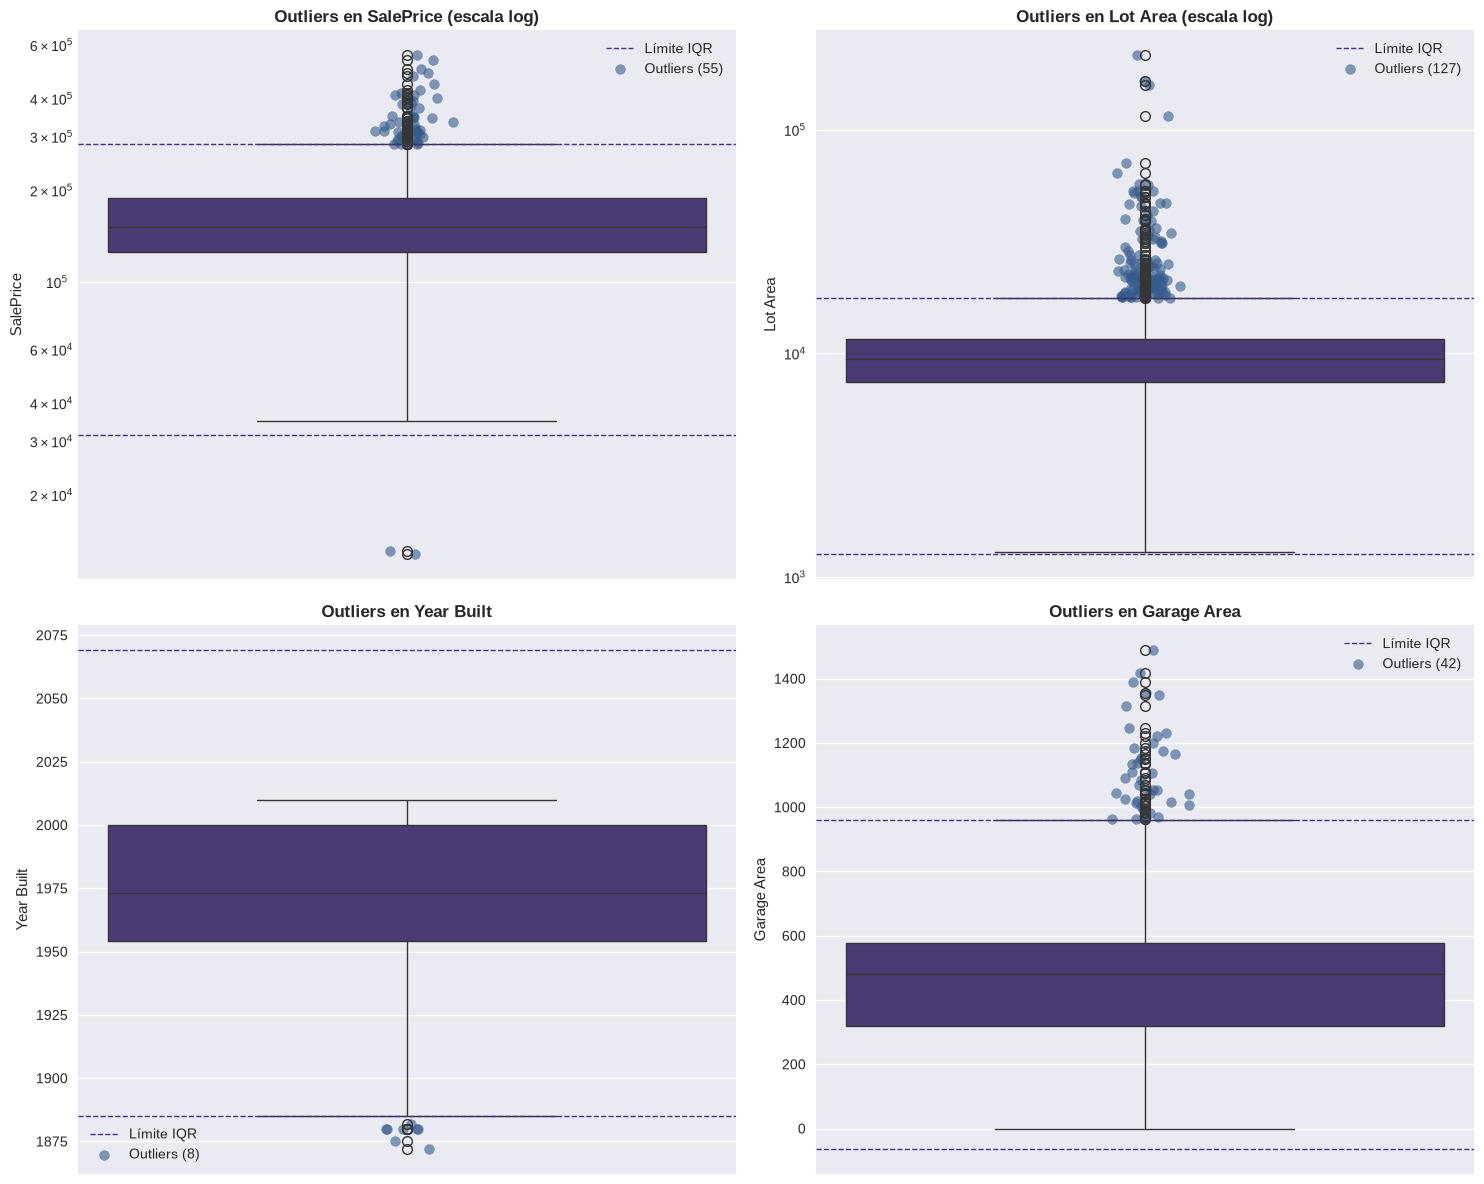

In [20]:
# === VISUALIZAR OUTLIERS ===

import os

os.makedirs('results/visualizaciones', exist_ok=True)

cols = ['SalePrice', 'Lot Area', 'Year Built', 'Garage Area']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))  # función para crear subplots
axes = axes.ravel()  # método para aplanar array

for i, col in enumerate(cols):
    if col not in df.columns:
        axes[i].set_visible(False)
        continue

    # convertir a numérico de forma segura
    y = pd.to_numeric(df[col], errors='coerce').dropna()

    if y.empty:
        axes[i].axis('off')
        axes[i].text(0.5, 0.5, f"{col}: sin datos numéricos", ha='center', va='center', fontsize=11)
        continue

    # Boxplot usando el vector numérico (evita inferencias de dtype de seaborn)
    sns.boxplot(y=y, ax=axes[i])  # función para boxplot
    axes[i].set_title(f'Outliers en {col}', fontweight='bold')
    axes[i].set_ylabel(col)

    # Outliers por IQR y bandas
    iqr_df, lower, upper = detect_outliers_iqr(df, col)
    out_vals = pd.to_numeric(iqr_df[col], errors='coerce').dropna()

    if np.isfinite(lower):
        axes[i].axhline(lower, linestyle='--', linewidth=1, label='Límite IQR')
    if np.isfinite(upper):
        axes[i].axhline(upper, linestyle='--', linewidth=1)

    # Marcar outliers con un leve jitter en X para que se vean
    if len(out_vals) > 0:
        jitter_x = np.random.normal(loc=0, scale=0.02, size=len(out_vals))
        axes[i].scatter(jitter_x, out_vals, alpha=0.6, s=50, label=f'Outliers ({len(out_vals)})') # función para scatter
        axes[i].legend()  # método para mostrar leyenda

    # Opcional: si la variable es muy sesgada, usar escala log
    if col in ['Lot Area', 'SalePrice'] and y.skew() > 1:
        axes[i].set_yscale('log')
        axes[i].set_title(f'Outliers en {col} (escala log)', fontweight='bold')

plt.tight_layout() # función para ajustar layout
plt.savefig('results/visualizaciones/outliers_analysis.png', dpi=300, bbox_inches='tight') # función para guardar
plt.show() # función para mostrar gráfico

In [21]:
def impute_missing_data(df, strategy="median"):
    df_imputed = df.copy()

    for col in df.columns:
        if df[col].isnull().any():

            if df[col].dtype in ["int64", "float64"]:

                if strategy == "mean":
                    df_imputed[col] = df_imputed[col].fillna(
                        df[col].mean()
                    )

                elif strategy == "median":
                    df_imputed[col] = df_imputed[col].fillna(
                        df[col].median()
                    )

                elif strategy == "mode":
                    df_imputed[col] = df_imputed[col].fillna(
                        df[col].mode()[0]
                    )

            else:
                df_imputed[col] = df_imputed[col].fillna(
                    df[col].mode()[0]
                )

    return df_imputed


strategies = ["mean", "median", "mode"]
imputed_datasets = {}

for strategy in strategies:
    imputed_datasets[strategy] = impute_missing_data(df, strategy)

    restantes = (
        imputed_datasets[strategy]
        .isnull()
        .sum()
        .sum()
    )

    print(
        f"Estrategia {strategy}: "
        f"{restantes} missing values restantes"
    )

Estrategia mean: 0 missing values restantes
Estrategia median: 0 missing values restantes
Estrategia mode: 0 missing values restantes


In [23]:
def smart_imputation(df, *, impute_saleprice=True):
    """Imputación inteligente según el significado de cada columna."""

    df_imputed = df.copy()

    # Asegurar que estas columnas sean numéricas
    for c in ["Year Built", "Garage Area", "SalePrice"]:
        if c in df_imputed.columns:
            df_imputed[c] = pd.to_numeric(
                df_imputed[c],
                errors="coerce"
            )

    # Year Built:
    # mediana por barrio y estilo -> barrio -> mediana global
    if {
        "Neighborhood",
        "House Style",
        "Year Built"
    }.issubset(df_imputed.columns):

        grp_med = (
            df_imputed
            .groupby(["Neighborhood", "House Style"])["Year Built"]
            .transform("median")
        )

        df_imputed["Year Built"] = (
            df_imputed["Year Built"].fillna(grp_med)
        )

        nb_med = (
            df_imputed
            .groupby("Neighborhood")["Year Built"]
            .transform("median")
        )

        df_imputed["Year Built"] = (
            df_imputed["Year Built"].fillna(nb_med)
        )

        df_imputed["Year Built"] = (
            df_imputed["Year Built"]
            .fillna(df_imputed["Year Built"].median())
        )

        df_imputed["Year Built"] = (
            df_imputed["Year Built"]
            .round()
            .astype("Int64")
        )

    # Garage Area:
    # crear indicador para recordar cuáles eran NaN
    if "Garage Area" in df_imputed.columns:

        df_imputed["GarageArea_was_na"] = (
            df_imputed["Garage Area"]
            .isna()
            .astype("Int8")
        )

        # Si tiene cero autos, se interpreta que no tiene garaje
        if "Garage Cars" in df_imputed.columns:

            no_garage_mask = (
                (df_imputed["Garage Cars"].fillna(0) == 0)
                & df_imputed["Garage Area"].isna()
            )

            df_imputed.loc[
                no_garage_mask,
                "Garage Area"
            ] = 0.0

        # Para el resto, mediana del barrio
        if "Neighborhood" in df_imputed.columns:

            med_gar = (
                df_imputed
                .groupby("Neighborhood")["Garage Area"]
                .transform("median")
            )

            df_imputed["Garage Area"] = (
                df_imputed["Garage Area"].fillna(med_gar)
            )

        # Si todavía queda algún NaN, mediana global
        df_imputed["Garage Area"] = (
            df_imputed["Garage Area"]
            .fillna(df_imputed["Garage Area"].median())
        )

    # SalePrice: mediana según el barrio
    if (
        impute_saleprice
        and {"Neighborhood", "SalePrice"}.issubset(df_imputed.columns)
    ):

        nb_price = (
            df_imputed
            .groupby("Neighborhood")["SalePrice"]
            .transform("median")
        )

        df_imputed["SalePrice"] = (
            df_imputed["SalePrice"].fillna(nb_price)
        )

        df_imputed["SalePrice"] = (
            df_imputed["SalePrice"]
            .fillna(df_imputed["SalePrice"].median())
        )

    # Garage Type: utilizar la moda
    if "Garage Type" in df_imputed.columns:

        if isinstance(
            df_imputed["Garage Type"].dtype,
            pd.CategoricalDtype
        ):
            df_imputed["Garage Type"] = (
                df_imputed["Garage Type"].astype("object")
            )

        mode_val = (
            df_imputed["Garage Type"]
            .dropna()
            .mode()
        )

        fill_val = (
            mode_val.iloc[0]
            if not mode_val.empty
            else "Unknown"
        )

        df_imputed["Garage Type"] = (
            df_imputed["Garage Type"].fillna(fill_val)
        )

    return df_imputed


df_smart_imputed = smart_imputation(df)

print("=== IMPUTACIÓN INTELIGENTE ===")
print(
    "Missing restantes:",
    int(df_smart_imputed.isnull().sum().sum())
)

df_smart_imputed.isna().sum().sort_values(ascending=False).head(20)

=== IMPUTACIÓN INTELIGENTE ===
Missing restantes: 15591


Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Finish      159
Garage Yr Blt      159
Bsmt Exposure       83
BsmtFin Type 2      81
BsmtFin Type 1      80
Bsmt Cond           80
Bsmt Qual           80
Mas Vnr Area        23
Bsmt Half Bath       2
Bsmt Full Bath       2
BsmtFin SF 1         1
dtype: int64

In [25]:
from pandas.api.types import is_numeric_dtype

# Copia del resultado de la imputación inteligente
df_completo = df_smart_imputed.copy()

# Columnas categóricas donde NaN significa que la característica no existe
structural_categorical = [
    "Pool QC",
    "Misc Feature",
    "Alley",
    "Fence",
    "Mas Vnr Type",
    "Fireplace Qu",
    "Garage Qual",
    "Garage Cond",
    "Garage Finish",
    "Garage Type",
    "Bsmt Exposure",
    "BsmtFin Type 1",
    "BsmtFin Type 2",
    "Bsmt Cond",
    "Bsmt Qual"
]

for col in structural_categorical:
    if col in df_completo.columns:
        # Convertir a object evita problemas si era category
        df_completo[col] = (
            df_completo[col]
            .astype("object")
            .fillna("No tiene")
        )

# Columnas numéricas donde NaN significa ausencia de la característica
structural_numeric = [
    "Mas Vnr Area",
    "Garage Yr Blt",
    "Bsmt Half Bath",
    "Bsmt Full Bath",
    "BsmtFin SF 1",
    "BsmtFin SF 2",
    "Bsmt Unf SF",
    "Total Bsmt SF",
    "Garage Cars",
    "Garage Area"
]

for col in structural_numeric:
    if col in df_completo.columns:
        df_completo[col] = (
            pd.to_numeric(
                df_completo[col],
                errors="coerce"
            )
            .fillna(0)
        )

# Lot Frontage: mediana del barrio y luego mediana global
if {
    "Lot Frontage",
    "Neighborhood"
}.issubset(df_completo.columns):

    frontage_barrio = (
        df_completo
        .groupby("Neighborhood")["Lot Frontage"]
        .transform("median")
    )

    df_completo["Lot Frontage"] = (
        df_completo["Lot Frontage"]
        .fillna(frontage_barrio)
        .fillna(df_completo["Lot Frontage"].median())
    )

# Completar cualquier NaN restante
for col in df_completo.columns:

    if not df_completo[col].isna().any():
        continue

    if is_numeric_dtype(df_completo[col]):
        mediana = df_completo[col].median()

        df_completo[col] = df_completo[col].fillna(
            mediana if pd.notna(mediana) else 0
        )

    else:
        df_completo[col] = (
            df_completo[col]
            .astype("object")
            .fillna("Desconocido")
        )

print("Missing restantes:", df_completo.isna().sum().sum())

df_smart_imputed = df_completo

Missing restantes: 0


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Separar variables predictoras y objetivo
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

# Dividir: 60% train, 20% validación y 20% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

print("=== SPLIT DE DATOS ===")
print(f"Train: {X_train.shape[0]} registros")
print(f"Valid: {X_valid.shape[0]} registros")
print(f"Test: {X_test.shape[0]} registros")

# Separar columnas numéricas y categóricas
numeric_columns = (
    X_train
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

categorical_columns = (
    X_train
    .select_dtypes(include=["object", "category"])
    .columns
    .tolist()
)

print(f"Columnas numéricas: {len(numeric_columns)}")
print(f"Columnas categóricas: {len(categorical_columns)}")

# Crear los imputadores
numeric_imputer = SimpleImputer(strategy="median")

categorical_imputer = SimpleImputer(
    strategy="most_frequent"
)

# Aprender los valores solamente con train
numeric_imputer.fit(X_train[numeric_columns])
categorical_imputer.fit(X_train[categorical_columns])

# Aplicar a train
X_train_numeric = numeric_imputer.transform(
    X_train[numeric_columns]
)

X_train_categorical = categorical_imputer.transform(
    X_train[categorical_columns]
)

# Aplicar a validación
X_valid_numeric = numeric_imputer.transform(
    X_valid[numeric_columns]
)

X_valid_categorical = categorical_imputer.transform(
    X_valid[categorical_columns]
)

# Aplicar a test
X_test_numeric = numeric_imputer.transform(
    X_test[numeric_columns]
)

X_test_categorical = categorical_imputer.transform(
    X_test[categorical_columns]
)

print(
    "\nAnti-leakage aplicado: "
    "fit solamente en train y transform en todos."
)

=== SPLIT DE DATOS ===
Train: 1758 registros
Valid: 586 registros
Test: 586 registros
Columnas numéricas: 38
Columnas categóricas: 43

Anti-leakage aplicado: fit solamente en train y transform en todos.


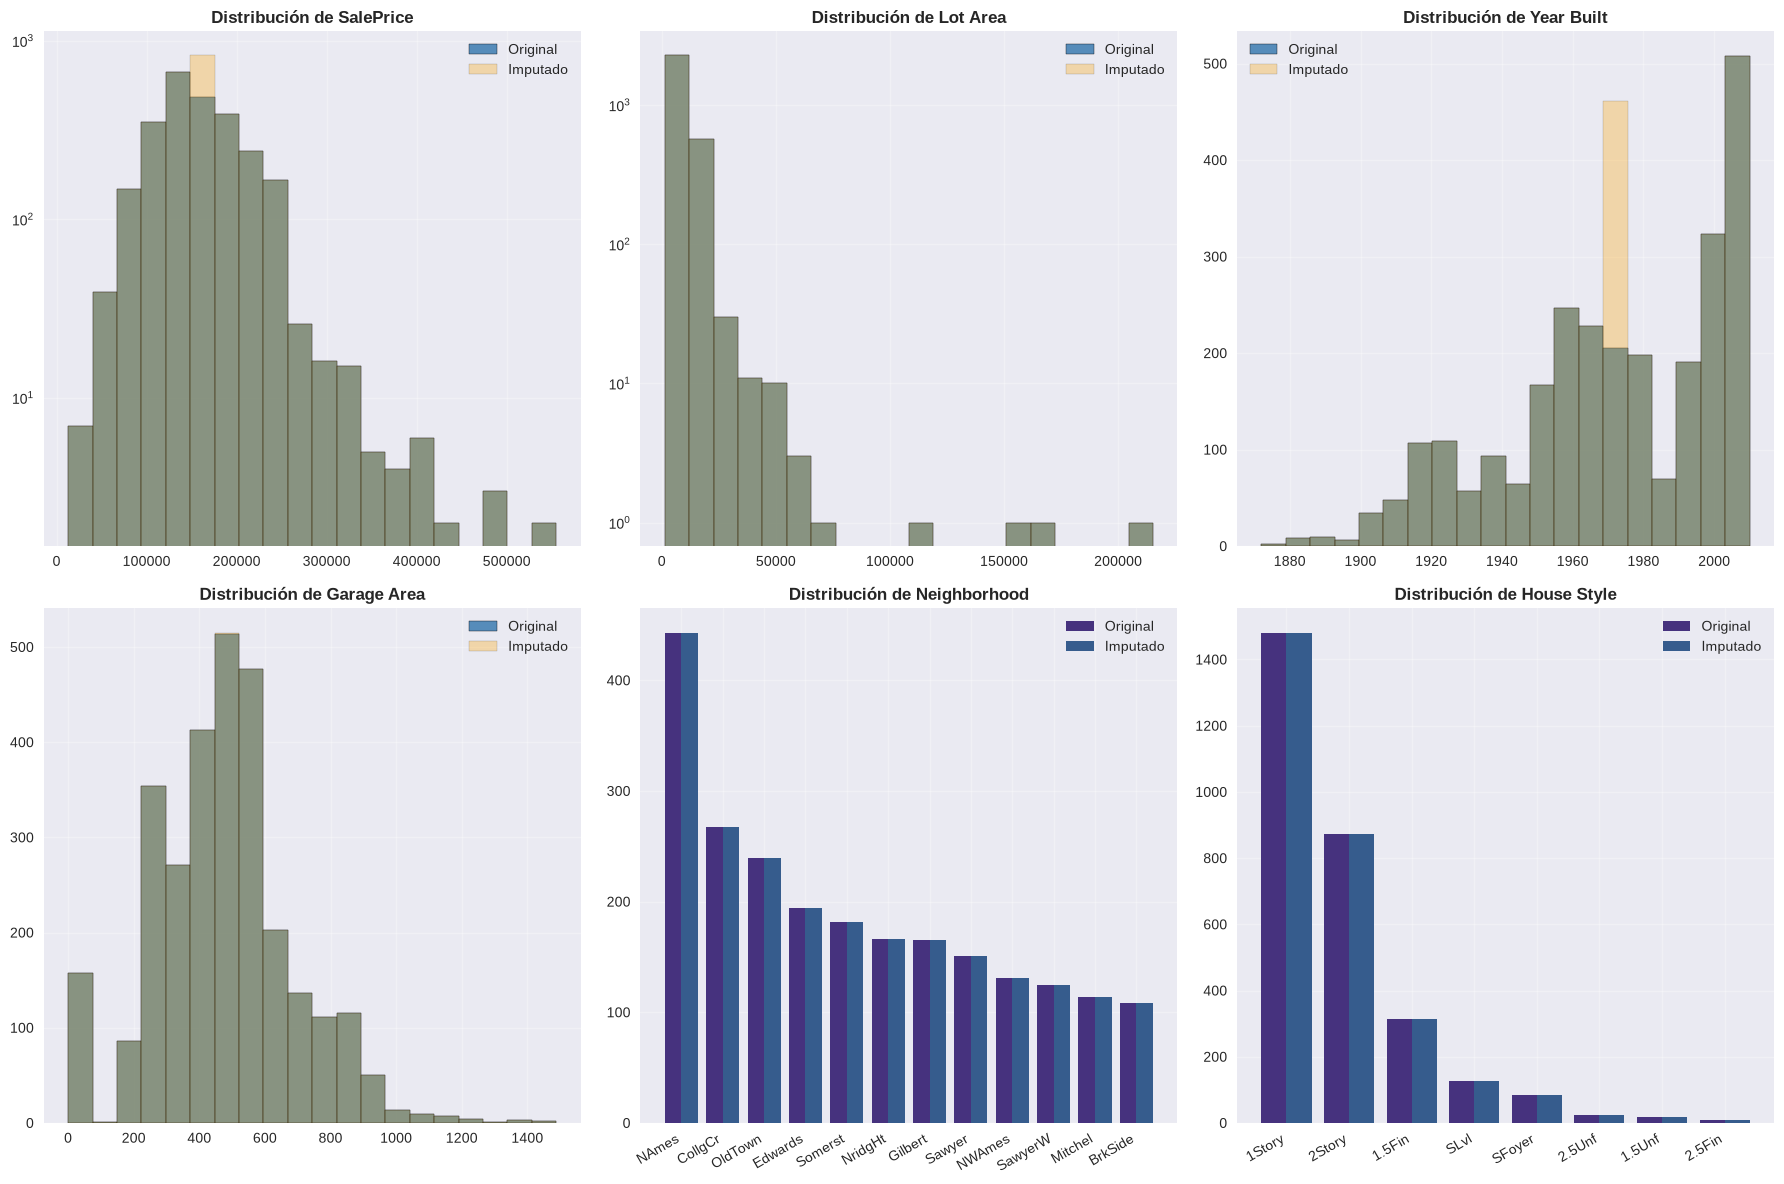

In [27]:
from pandas.api.types import is_numeric_dtype

os.makedirs("results/visualizaciones", exist_ok=True)

# Crear copia imputada
df_imputed = df.copy()

for col in df.columns:
    s = df[col]

    # Intentar tratar la columna como numérica
    if is_numeric_dtype(s) or s.dtype == "object":

        s_num = pd.to_numeric(s, errors="coerce")

        if s_num.notna().any():
            df_imputed[col] = s_num.fillna(
                s_num.median()
            )
            continue

    # Si es categórica, rellenar con moda
    moda = s.dropna().mode()

    fill_val = (
        moda.iloc[0]
        if not moda.empty
        else "Unknown"
    )

    df_imputed[col] = s.fillna(fill_val)


# Comparar distribuciones
fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 12)
)

axes = axes.ravel()

cols_to_plot = [
    "SalePrice",
    "Lot Area",
    "Year Built",
    "Garage Area",
    "Neighborhood",
    "House Style"
]

for i, col in enumerate(cols_to_plot):

    if col not in df.columns:
        axes[i].axis("off")
        axes[i].set_title(
            f"{col} no existe",
            fontweight="bold"
        )
        continue

    s_orig = df[col]
    s_imp = df_imputed[col]

    s_orig_num = pd.to_numeric(
        s_orig,
        errors="coerce"
    )

    s_imp_num = pd.to_numeric(
        s_imp,
        errors="coerce"
    )

    # Variables numéricas: histogramas
    if (
        s_orig_num.notna().any()
        and s_imp_num.notna().any()
    ):

        data_combined = pd.concat([
            s_orig_num.dropna(),
            s_imp_num.dropna()
        ])

        bins = np.histogram_bin_edges(
            data_combined,
            bins=20
        )

        axes[i].hist(
            s_orig_num.dropna(),
            bins=bins,
            alpha=0.9,
            label="Original",
            color="steelblue",
            edgecolor="black"
        )

        axes[i].hist(
            s_imp_num.dropna(),
            bins=bins,
            alpha=0.3,
            label="Imputado",
            color="orange",
            edgecolor="black"
        )

        if (
            col in ["Lot Area", "SalePrice"]
            and s_orig_num.dropna().skew() > 1
        ):
            axes[i].set_yscale("log")

    # Variables categóricas: gráfico de barras
    else:
        K = 12

        vc_orig = (
            s_orig.astype("object")
            .fillna("Missing")
            .value_counts()
            .head(K)
        )

        vc_imp = (
            s_imp.astype("object")
            .fillna("Missing")
            .value_counts()
            .head(K)
        )

        cats = list(
            dict.fromkeys(
                list(vc_orig.index)
                + list(vc_imp.index)
            )
        )[:K]

        vc_orig = vc_orig.reindex(
            cats,
            fill_value=0
        )

        vc_imp = vc_imp.reindex(
            cats,
            fill_value=0
        )

        x = np.arange(len(cats))
        w = 0.4

        axes[i].bar(
            x - w / 2,
            vc_orig.values,
            width=w,
            label="Original"
        )

        axes[i].bar(
            x + w / 2,
            vc_imp.values,
            width=w,
            label="Imputado"
        )

        axes[i].set_xticks(x)

        axes[i].set_xticklabels(
            cats,
            rotation=30,
            ha="right"
        )

    axes[i].set_title(
        f"Distribución de {col}",
        fontweight="bold"
    )

    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "results/visualizaciones/distribution_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Columnas seleccionadas: ['SalePrice', 'Lot Area', 'Year Built', 'Garage Area', 'Overall Qual', 'Gr Liv Area', 'Total Bsmt SF']


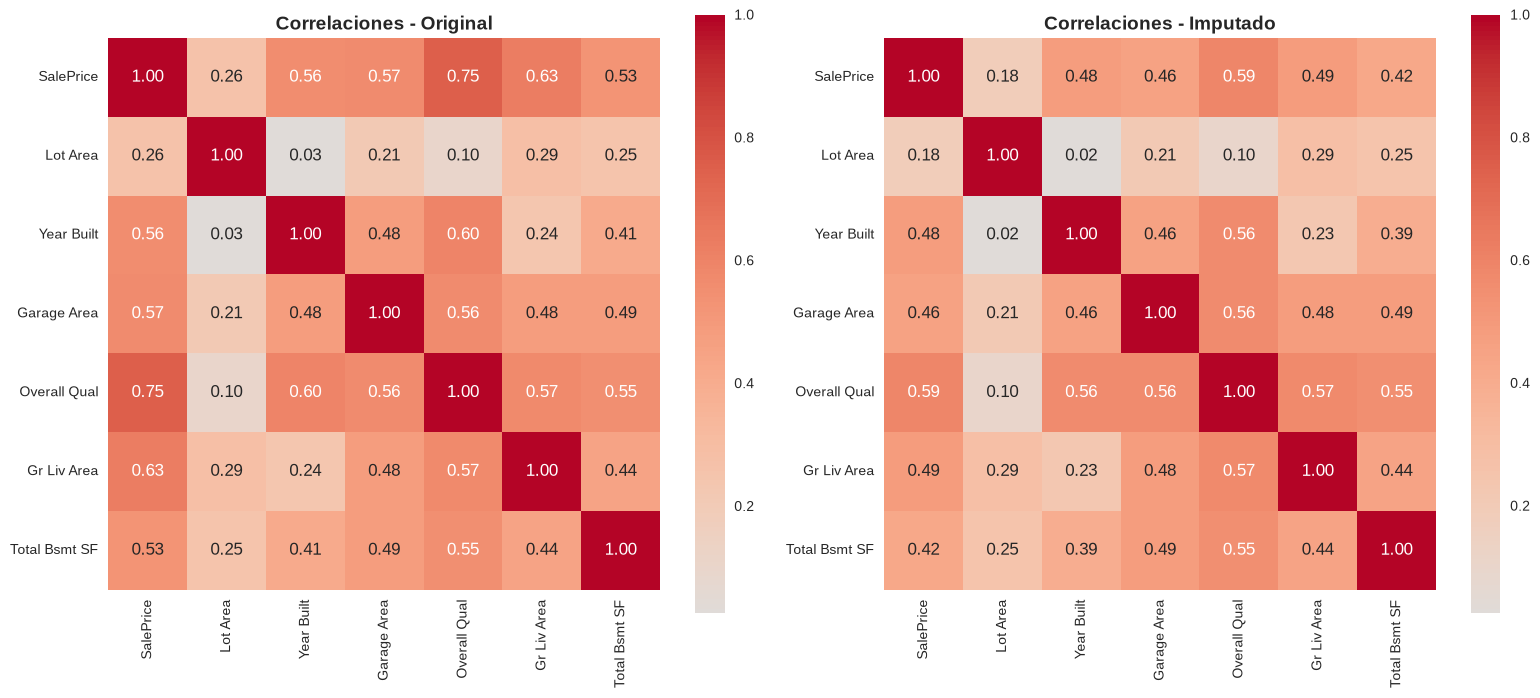


=== DIFERENCIAS EN CORRELACIONES ===
Cambios en correlaciones (Imputado - Original):
               SalePrice  Lot Area  Year Built  Garage Area  Overall Qual  \
SalePrice          0.000    -0.074      -0.078       -0.105        -0.165   
Lot Area          -0.074     0.000      -0.001       -0.000         0.000   
Year Built        -0.078    -0.001       0.000       -0.022        -0.031   
Garage Area       -0.105    -0.000      -0.022        0.000        -0.000   
Overall Qual      -0.165     0.000      -0.031       -0.000         0.000   
Gr Liv Area       -0.141     0.000      -0.010       -0.000         0.000   
Total Bsmt SF     -0.103     0.000      -0.018       -0.000        -0.000   

               Gr Liv Area  Total Bsmt SF  
SalePrice           -0.141         -0.103  
Lot Area             0.000          0.000  
Year Built          -0.010         -0.018  
Garage Area         -0.000         -0.000  
Overall Qual         0.000         -0.000  
Gr Liv Area          0.000       

In [29]:
important_cols = [
    "SalePrice",
    "Lot Area",
    "Year Built",
    "Garage Area",
    "Overall Qual",
    "Gr Liv Area",
    "Total Bsmt SF"
]

available_cols = [
    c
    for c in important_cols
    if c in df.columns
]

print(
    "Columnas seleccionadas:",
    available_cols
)

df_num_original = (
    df[available_cols]
    .apply(pd.to_numeric, errors="coerce")
)

df_num_imputed = (
    df_imputed[available_cols]
    .apply(pd.to_numeric, errors="coerce")
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 8)
)

corr_original = df_num_original.corr(
    numeric_only=True
)

sns.heatmap(
    corr_original,
    annot=True,
    cmap="coolwarm",
    center=0,
    ax=axes[0],
    square=True,
    fmt=".2f",
    cbar_kws={"shrink": 0.8}
)

axes[0].set_title(
    "Correlaciones - Original",
    fontweight="bold",
    fontsize=14
)

corr_imputed = df_num_imputed.corr(
    numeric_only=True
)

sns.heatmap(
    corr_imputed,
    annot=True,
    cmap="coolwarm",
    center=0,
    ax=axes[1],
    square=True,
    fmt=".2f",
    cbar_kws={"shrink": 0.8}
)

axes[1].set_title(
    "Correlaciones - Imputado",
    fontweight="bold",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "results/visualizaciones/correlation_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n=== DIFERENCIAS EN CORRELACIONES ===")

corr_diff = corr_imputed - corr_original

print(
    "Cambios en correlaciones "
    "(Imputado - Original):"
)

print(corr_diff.round(3))

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


def create_cleaning_pipeline():
    """Crear pipeline de limpieza reproducible."""

    numeric_features = [
        "SalePrice",
        "Lot Area",
        "Year Built",
        "Garage Area"
    ]

    categorical_features = [
        "Neighborhood",
        "House Style",
        "Garage Type"
    ]

    numeric_transformer = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "scaler",
                StandardScaler()
            )
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            )
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                numeric_transformer,
                numeric_features
            ),
            (
                "cat",
                categorical_transformer,
                categorical_features
            )
        ]
    )

    return preprocessor


preprocessor = create_cleaning_pipeline()

X_cleaned = preprocessor.fit_transform(df)

print(
    f"Shape después del pipeline: "
    f"{X_cleaned.shape}"
)

print(
    f"Tipo de datos: "
    f"{type(X_cleaned)}"
)

Shape después del pipeline: (2930, 46)
Tipo de datos: <class 'scipy.sparse._csr.csr_matrix'>


## Parte B: análisis crítico

### 1. ¿Qué tipo de missing data se identificó?

En `Garage Type` se puede considerar MCAR porque los valores faltantes
fueron generados aleatoriamente y no dependen de otras variables.

En `Year Built` se puede considerar MAR porque la probabilidad de que el
dato falte se relaciona con información observada, como la antigüedad o
las características de la vivienda.

En `Garage Area` se puede considerar MNAR porque la ausencia del dato
puede estar relacionada con el valor que debería representar. Por
ejemplo, una vivienda sin garaje puede tener el área faltante justamente
porque no existe un garaje.

En `SalePrice` se puede considerar MAR porque los valores faltantes
pueden relacionarse con variables conocidas, como el barrio o las
características de la propiedad.

### 2. ¿Por qué se eligieron esas estrategias de imputación?

Para las variables numéricas se utilizó principalmente la mediana porque
es menos sensible a valores extremos que la media. Para las variables
categóricas se utilizó la moda porque representa la categoría más
frecuente.

También se aplicaron estrategias por grupo. Por ejemplo, `Year Built` se
completó usando viviendas del mismo barrio y estilo, mientras que
`SalePrice` se completó utilizando la mediana del barrio. Esto conserva
mejor las diferencias existentes entre distintos tipos de vivienda.

Una alternativa sería usar KNNImputer o IterativeImputer, aunque son
métodos más complejos y menos fáciles de explicar.

### 3. ¿Cómo puede afectar la imputación a diferentes grupos?

La imputación puede modificar artificialmente las características de
algunos barrios o tipos de vivienda. Por ejemplo, rellenar todos los
precios con la mediana global podría aumentar los precios de barrios
económicos y reducir los de barrios caros.

Por eso es preferible utilizar información de grupos similares y
comparar las distribuciones antes y después de la imputación.

### 4. ¿Qué información adicional se necesita sobre los outliers?

Sería útil conocer el contexto de cada propiedad, la unidad de medida,
los límites posibles de las variables y si hubo errores durante la carga
de los datos.

Un valor extremo no necesariamente es incorrecto. Una casa muy grande o
cara puede ser un caso real. Antes de eliminarla habría que comprobar su
información original y entender el contexto de negocio.

### 5. ¿Cómo se garantiza que el pipeline sea reproducible?

Se utiliza un pipeline de scikit-learn que documenta y ejecuta siempre
las mismas transformaciones. También se fija `random_state=42` en las
divisiones aleatorias y se ajustan los imputadores solamente con el
conjunto de entrenamiento.

De esta manera se evitan cambios accidentales, se reduce el data leakage
y otra persona puede repetir el procedimiento.

In [31]:
from sklearn.impute import KNNImputer

bonus_numeric_cols = [
    "SalePrice",
    "Lot Area",
    "Year Built",
    "Garage Area"
]

bonus_numeric_cols = [
    c
    for c in bonus_numeric_cols
    if c in df.columns
]

df_bonus_numeric = (
    df[bonus_numeric_cols]
    .apply(pd.to_numeric, errors="coerce")
)

knn_imputer = KNNImputer(n_neighbors=5)

knn_result = knn_imputer.fit_transform(
    df_bonus_numeric
)

df_knn_imputed = pd.DataFrame(
    knn_result,
    columns=bonus_numeric_cols,
    index=df.index
)

print("Missing después de KNN:")
print(df_knn_imputed.isna().sum())

Missing después de KNN:
SalePrice      0
Lot Area       0
Year Built     0
Garage Area    0
dtype: int64


In [32]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

iterative_imputer = IterativeImputer(
    random_state=42,
    max_iter=10
)

iterative_result = iterative_imputer.fit_transform(
    df_bonus_numeric
)

df_iterative_imputed = pd.DataFrame(
    iterative_result,
    columns=bonus_numeric_cols,
    index=df.index
)

print("Missing después de IterativeImputer:")
print(df_iterative_imputed.isna().sum())

Missing después de IterativeImputer:
SalePrice      0
Lot Area       0
Year Built     0
Garage Area    0
dtype: int64


In [33]:
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer

bonus_data = SimpleImputer(
    strategy="median"
).fit_transform(df_bonus_numeric)

isolation_forest = IsolationForest(
    contamination=0.1,
    random_state=42
)

isolation_labels = isolation_forest.fit_predict(
    bonus_data
)

df_isolation = df.copy()

df_isolation["IsolationForest_outlier"] = (
    isolation_labels == -1
)

print(
    "Outliers encontrados con Isolation Forest:",
    df_isolation["IsolationForest_outlier"].sum()
)

df_isolation.loc[
    df_isolation["IsolationForest_outlier"],
    bonus_numeric_cols
].head(10)

Outliers encontrados con Isolation Forest: 293


,SalePrice,Lot Area,Year Built,Garage Area
0,215000.0,31770,1960.0,528.0
15,538000.0,53504,2003.0,841.0
46,500000.0,14300,2003.0,958.0
62,325000.0,12256,1994.0,712.0
65,410000.0,14720,1995.0,666.0
104,267916.0,12853,2010.0,852.0
125,84900.0,13260,1962.0,0.0
130,76500.0,5350,1940.0,0.0
169,80400.0,4800,1900.0,240.0
170,96500.0,8800,1910.0,0.0


In [34]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.1
)

lof_labels = lof.fit_predict(bonus_data)

df_lof = df.copy()

df_lof["LOF_outlier"] = (
    lof_labels == -1
)

print(
    "Outliers encontrados con LOF:",
    df_lof["LOF_outlier"].sum()
)

Outliers encontrados con LOF: 293


In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

bonus_scaled = StandardScaler().fit_transform(
    bonus_data
)

one_class_svm = OneClassSVM(
    nu=0.1,
    kernel="rbf",
    gamma="scale"
)

svm_labels = one_class_svm.fit_predict(
    bonus_scaled
)

df_svm = df.copy()

df_svm["SVM_outlier"] = (
    svm_labels == -1
)

print(
    "Outliers encontrados con One-Class SVM:",
    df_svm["SVM_outlier"].sum()
)

Outliers encontrados con One-Class SVM: 294


In [36]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(
    bonus_scaled
)

df_dbscan = df.copy()
df_dbscan["DBSCAN_cluster"] = dbscan_labels

print(
    "Posibles outliers de DBSCAN:",
    (dbscan_labels == -1).sum()
)

Posibles outliers de DBSCAN: 267


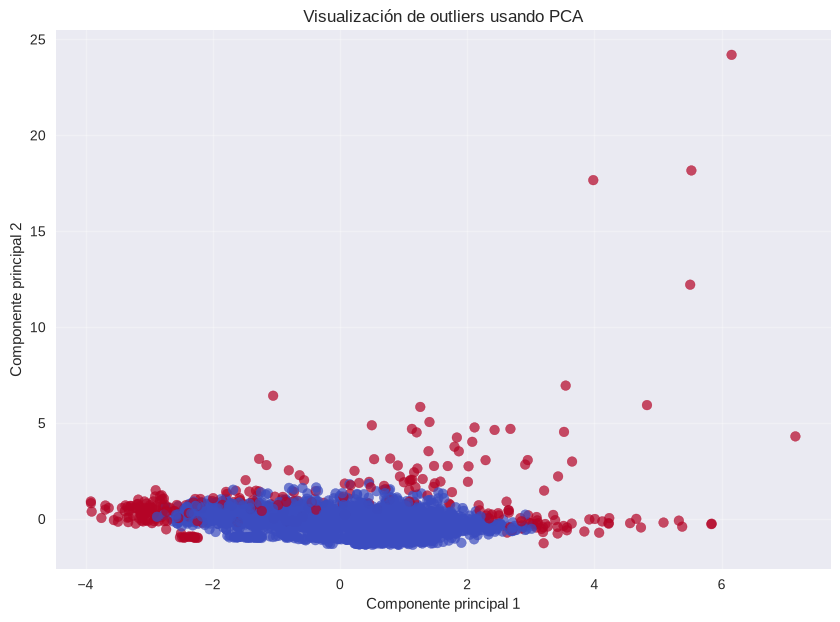

In [37]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_result = pca.fit_transform(
    bonus_scaled
)

plt.figure(figsize=(10, 7))

plt.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    c=(isolation_labels == -1),
    cmap="coolwarm",
    alpha=0.7
)

plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Visualización de outliers usando PCA")
plt.grid(True, alpha=0.3)
plt.show()